<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


This exercise, will work with a cleaned dataset to perform exploratory data analysis (EDA). Will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


This exercise will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [4]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [5]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [6]:
plt.figure(figsize=(8,5))
import seaborn as sns
Yearly = df["ConvertedCompYearly"].dropna().sort_values(ascending = False)
print(Yearly.head())
print("MAX", df['ConvertedCompYearly'].max())
print("DESCRIBE",df['ConvertedCompYearly'].describe())
print ("SUM", (df['ConvertedCompYearly'] == 0).sum())
print ("SMALLEST",df['ConvertedCompYearly'].nsmallest(5))
print("LARGEST", df["ConvertedCompYearly"].nlargest(5))
print ("LESS 1000", (df['ConvertedCompYearly'] < 1000).sum())

15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
Name: ConvertedCompYearly, dtype: float64
MAX 16256603.0
DESCRIBE count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64
SUM 0
SMALLEST 3890    1.0
5069    1.0
6102    1.0
6963    1.0
7773    1.0
Name: ConvertedCompYearly, dtype: float64
LARGEST 15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
Name: ConvertedCompYearly, dtype: float64
LESS 1000 545

<Figure size 800x500 with 0 Axes>

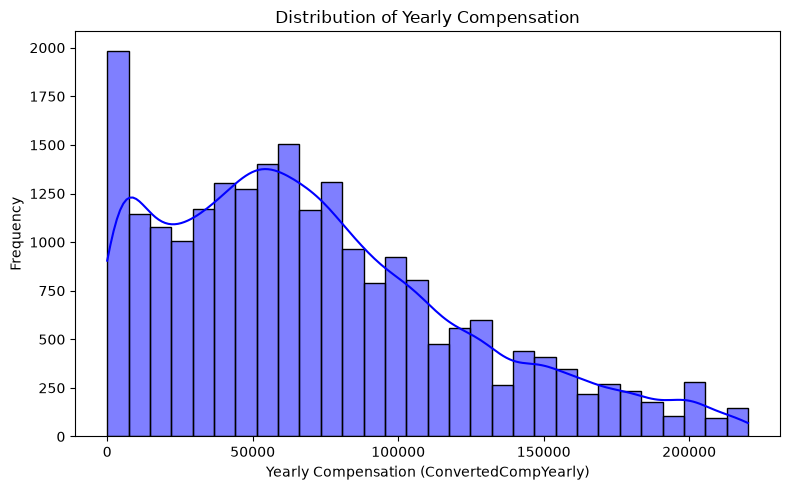

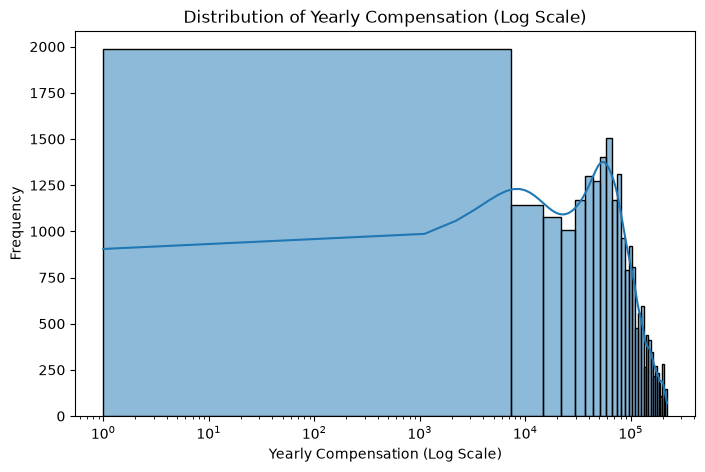

In [7]:

q1 = df["ConvertedCompYearly"].quantile(.25)
q2 = df["ConvertedCompYearly"].quantile(.75)
q3 = q2-q1
lower_bound = q1-1.5*q3
upper_bound = q2+1.5*q3

filtered = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

plt.figure(figsize=(8, 5))
sns.histplot(filtered["ConvertedCompYearly"].dropna(), bins =30, kde =True, color = "blue")
plt.title("Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(
    filtered['ConvertedCompYearly'].dropna(),
    bins=30,
    kde=True
)
plt.xscale('log')
plt.title('Distribution of Yearly Compensation (Log Scale)')
plt.xlabel('Yearly Compensation (Log Scale)')
plt.ylabel('Frequency')

plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [9]:
Employed_fulltime = df[df["Employment"] == "Employed, full-time"]
Median_comp = Employed_fulltime["ConvertedCompYearly"].dropna().median()
print (Median_comp)


69814.0

In [10]:
df["Country"].head()

0                             United States of America
1    United Kingdom of Great Britain and Northern I...
2    United Kingdom of Great Britain and Northern I...
3                                               Canada
4                                               Norway
Name: Country, dtype: str

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


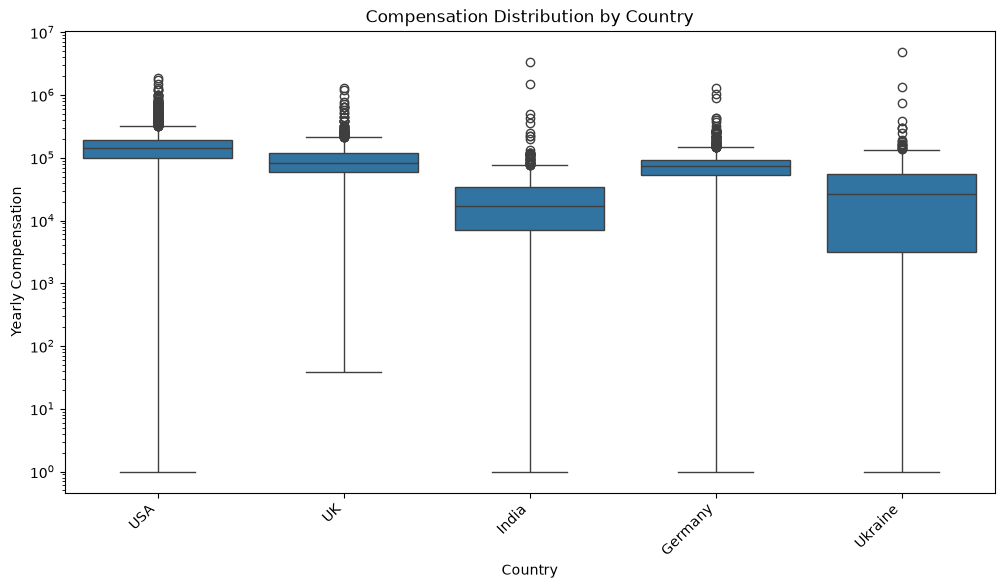

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
df["Country"] = df["Country"].replace({"United Kingdom of Great Britain and Northern Ireland":"UK", "United States of America":"USA"})
top_countries = df["Country"].value_counts().head().index
df_top = df[df["Country"].isin(top_countries)]

plt.figure(figsize =(12,6))
sns.boxplot(x="Country", y= "ConvertedCompYearly", data = df_top)
plt.title("Compensation Distribution by Country")
plt.xlabel("Country")
plt.xticks(rotation =45, ha= "right")
plt.ylabel("Yearly Compensation")
plt.yscale("log")
plt.show()

Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [12]:
q1 = df["ConvertedCompYearly"].quantile(.25)
q3= df["ConvertedCompYearly"].quantile(.75)
iqr = q3-q1
lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

refine_data = df[(df["ConvertedCompYearly"] >= lower_bound) &
                (df["ConvertedCompYearly"] <=upper_bound)]
print(refine_data["ConvertedCompYearly"])


72         7322.0
374       30074.0
379       91295.0
385       53703.0
389      110000.0
           ...   
41179     15600.0
41180     44640.0
41184    170000.0
41185    116844.0
41186     12000.0
Name: ConvertedCompYearly, Length: 22457, dtype: float64

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000

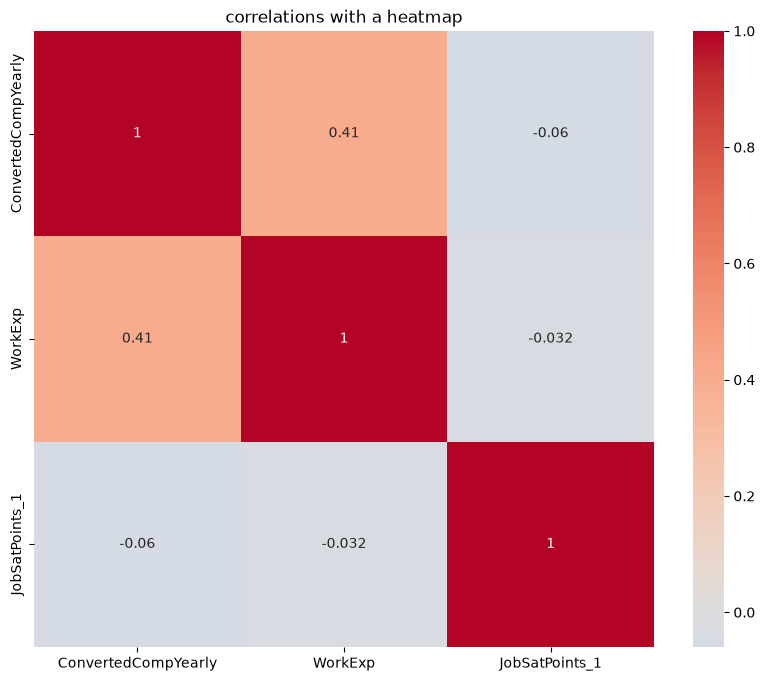

In [13]:
df_corr = refine_data[["ConvertedCompYearly", "WorkExp", "JobSatPoints_1"]].dropna().corr()
print(df_corr)
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, center = 0, cmap= "coolwarm")
plt.title("correlations with a heatmap")
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


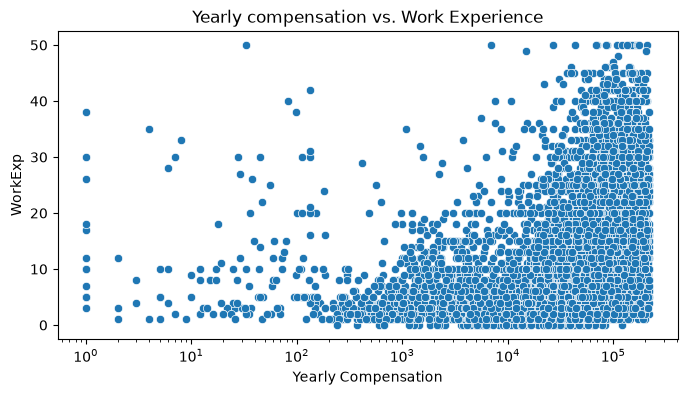

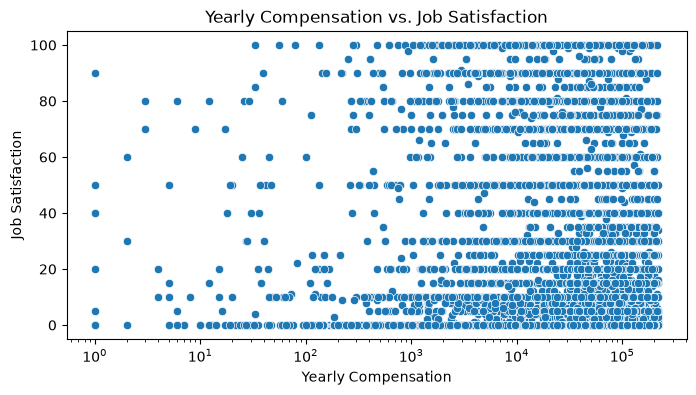

In [14]:
corr_work = refine_data[["ConvertedCompYearly", "WorkExp"]].dropna()
corr_jobsat= refine_data[["ConvertedCompYearly", "JobSatPoints_1"]].dropna()

plt.figure(figsize=(8,4))
sns.scatterplot(corr_work, x= "ConvertedCompYearly", y = "WorkExp")
plt.title("Yearly compensation vs. Work Experience")
plt.xlabel("Yearly Compensation")
plt.ylabel("WorkExp")
plt.xscale("log")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(corr_jobsat, x= "ConvertedCompYearly", y = "JobSatPoints_1")
plt.title("Yearly Compensation vs. Job Satisfaction")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.xscale("log")
plt.show()

<h3>Summary</h3>


This exercise practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.



Copyright © IBM Corporation. All rights reserved.
